# Постановка задачи
Вы стажируетесь в стартапе и вместе с командой работаете над улучшением сервиса по распознаванию лиц. Вашей компании поступил запрос на применение разработанного сервиса в рамках IT-конференции, спикерами на которой будут знаменитые люди.

Многие люди используют распознавание лиц просто как способ разблокировать телефон или отсортировать фотографии и даже не представляют всех возможностей этого мощного инструмента. Распознавание лиц активно используется маркетологами.
→ Coca-Cola использовала распознавание лиц по-разному во всём мире. Например, некоторые торговые автоматы Coca-Cola в Китае вознаграждали клиентов за переработку ёмкостей бренда, а на торговых автоматах в Австралии размещалась персонализированная реклама.

→ MAC Cosmetics используют технологию распознавания лиц в некоторых офлайн-магазинах, что позволяет покупателям виртуально «примерить» макияж с помощью имеющихся в магазине зеркал с дополненной реальностью.

Теперь давайте поможем и камерам их узнавать. Для этого обучим пятиклассовый классификатор, используя всю мощь предобученных сетей.

**Бизнес-задача:** разработать классификатор лиц, который автоматически определяет, кто из 5 известных спикеров изображён на фотографии, чтобы использовать его в сервисе распознавания лиц на IT-конференции.

**Техническая задача для специалиста:** обучить многоклассовую модель классификации изображений на 5 классов с использованием transfer learning и добиться accuracy > 0.85 на валидационной выборке, после чего визуализировать предсказания модели.

**Основные цели проекта:**
* Обучить классификатор для распознавания 5 человек.

* Использовать предобученную нейросеть и transfer learning.

* Достичь accuracy > 0.85 на валидационной выборке.

* Визуализировать результаты работы модели.

# Загрузка из гитхаб

In [31]:
!git clone --filter=blob:none --no-checkout https://github.com/Ar1sha/sf.git
%cd /content/sf
!git sparse-checkout set "Computer vision engineer"
!git checkout master
%cd "/content/sf/Computer vision engineer"

fatal: destination path 'sf' already exists and is not an empty directory.
/content/sf
Already on 'master'
Your branch is up to date with 'origin/master'.
/content/sf/Computer vision engineer


# Загрузка библиотек

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

# Загрузка данных

In [33]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
train_dir = "./data/train"
valid_dir = "./data/valid"

train = datasets.ImageFolder(train_dir, transform=transform)
valid = datasets.ImageFolder(valid_dir, transform=transform)

# DataLoader для формирования батчей

In [34]:
train_loader = DataLoader(
    train,
    batch_size = 32,
    shuffle=True
)

valid_loader = DataLoader(
    valid,
    batch_size = 32,
    shuffle=False
)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Проверка Data Loader, батч

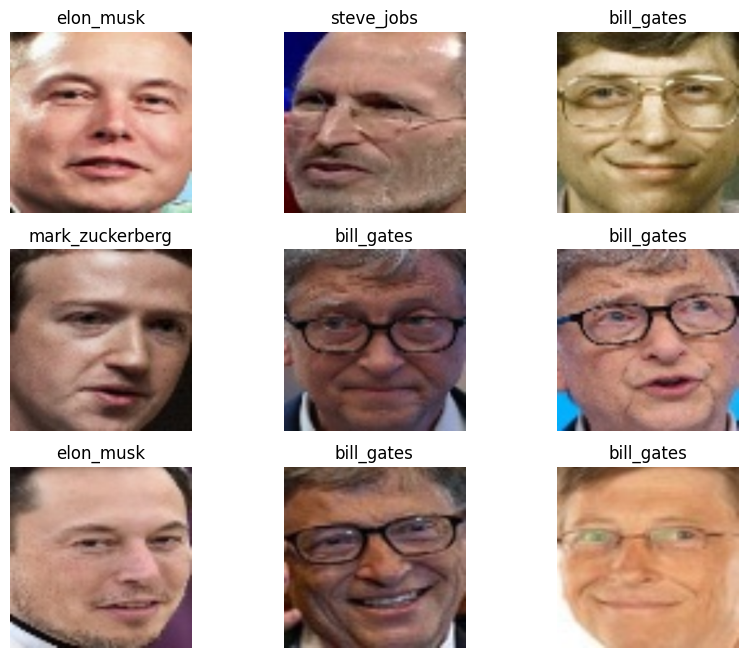

In [35]:
plt.figure(figsize=(10,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(train.classes[labels[i]])
    plt.axis("off")
plt.show()

# Предобученная модель

In [36]:
model = models.resnet18(weights='DEFAULT')
model.fc = torch.nn.Linear(model.fc.in_features, 5)
print(model.fc) # последний слой классификатора на 5 классов

Linear(in_features=512, out_features=5, bias=True)


# Критерий и опимизация

In [37]:
criterion = torch.nn.CrossEntropyLoss() # подходит для многоклассовой классификации
optimizer = torch.optim.Adam(model.parameters(),lr=0.001) #Адаптивный и базовый оптимизатор

In [38]:
# Подключаем cuda, если доступен, если нет- cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    # Обнуляем предыдущие градиенты
    optimizer.zero_grad()

    # Предсказание модели
    outputs = model(images)

    # Считаем ошибку предсказания модели
    loss= criterion(outputs,labels)

    # Вычисляем градиент
    loss.backward()

    # Обновляем веса
    optimizer.step()

In [39]:
for epoch in range(5):
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss= criterion(outputs,labels)

    loss.backward()
    optimizer.step()


In [40]:
# Модель в режим оценки
model.eval()
correct = 0
total = 0
# Оценка точности тренировочной выборки
for images, labels in train_loader:
  images = images.to(device)
  labels = labels.to(device)

  outputs = model(images)
  predictions = outputs.argmax(dim=1)
  correct += (predictions == labels).sum().item()
  total += labels.size(0)
accuracy = correct/total
print(f"Метрика accuracy для train выборки: {round(accuracy,3)}")


correct = 0
total = 0
# Оценка точности валидационной выборки
for images, labels in valid_loader:
  images = images.to(device)
  labels = labels.to(device)

  outputs = model(images)
  predictions = outputs.argmax(dim=1)
  correct += (predictions == labels).sum().item()
  total += labels.size(0)
accuracy = correct/total
print(f"Метрика accuracy для validation выборки: {round(accuracy,3)}")


Метрика accuracy для train выборки: 0.975
Метрика accuracy для validation выборки: 0.967


# Вывод:

Нет переобучения. Модель построенна хорошо.

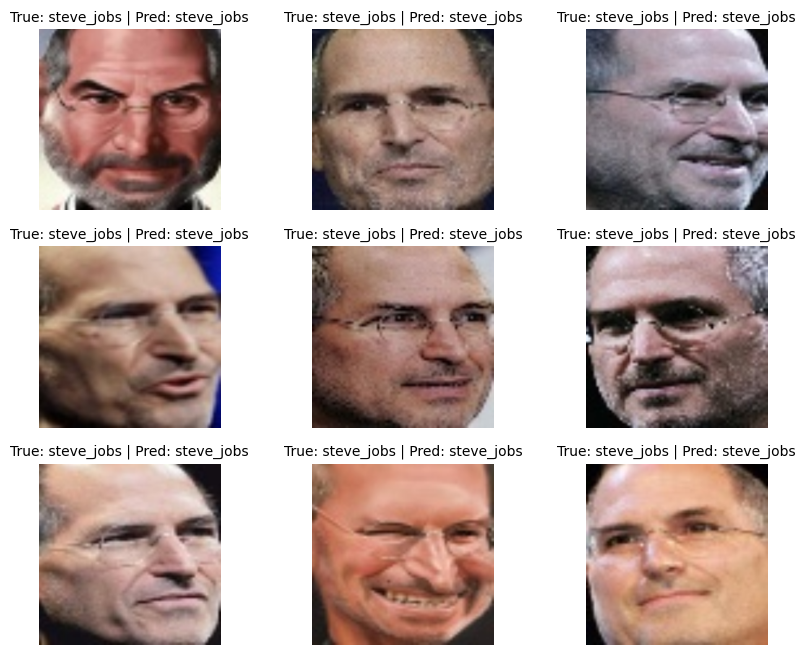

In [42]:
# Итоговая визуализация результатов
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
predictions = outputs.argmax(dim=1)

plt.figure(figsize=(10,8))

for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(images[i].cpu().permute(1,2,0))
  plt.title(
    f"True: {valid.classes[labels[i].item()]} | "
    f"Pred: {valid.classes[predictions[i].item()]}",
    fontsize=10
)
  plt.axis("off")
plt.show()

# Вывод проекта:

Обучена модель ResNet18. Достигнута цель проекта - accuracy > 0.85. Модель справляется с поставленной задачей.